In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import (
    norm,
    binom,
    poisson,
    binomtest,
    ttest_ind,
    ttest_1samp,
    chi2_contingency,
    pearsonr,
    spearmanr,
)
# Gerekli: pip install numpy matplotlib scipy



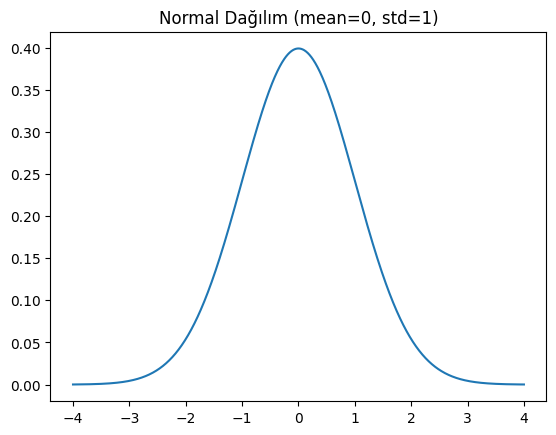

In [3]:
# --- Normal dağılım ---
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, loc=0, scale=1))
plt.title("Normal Dağılım (mean=0, std=1)")
plt.show()




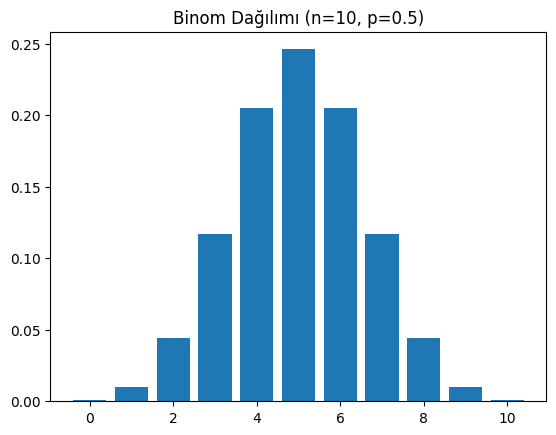

In [4]:
# --- Binom dağılımı ---
n, p = 10, 0.5
x = np.arange(0, n+1)
plt.bar(x, binom.pmf(x, n, p))
plt.title("Binom Dağılımı (n=10, p=0.5)")
plt.show()



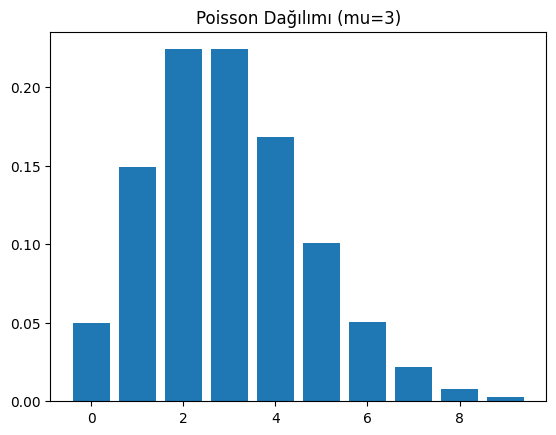

In [15]:
# --- Poisson dağılımı ---
mu = 3
x = np.arange(0, 10)
plt.bar(x, poisson.pmf(x, mu))
plt.title("Poisson Dağılımı (mu=3)")
plt.show()

## p-değeri, t-test, ki-kare, korelasyon ve nedensellik

**p-değeri:** H₀ doğru iken, gözlenen sonuçtan (veya daha uçta) en az bu kadar aşırı bir sonuç elde etme olasılığı. Küçük p → veriye göre H₀’ü reddetmek için güçlü kanıt (eşik çoğu alanda 0.05).

**Dikkat:** p-değeri hipotezin *doğruluğunu* vermez; tek başına etki büyüklüğünü de ölçmez.

In [ ]:
# --- p-değeri örneği: adil madde (p=0.5) ile 10 atışta 8 yazı ---
# H0: p = 0.5  |  İki kuyruklu: "8 veya daha uç" tüm kuyruklar
res = binomtest(k=8, n=10, p=0.5, alternative="two-sided")
print("p-değeri (iki kuyruk):", res.pvalue)

# Karşılaştırma: tek kuyruk "p > 0.5" (sadece çok fazla yazı tarafı)
res_g = binomtest(k=8, n=10, p=0.5, alternative="greater")
print("p-değeri (greater):", res_g.pvalue)

# Normal yaklaşım: z-skoru ve iki kuyruklu p (örnek)
z = 2.0
p_iki = 2 * min(norm.cdf(z), norm.sf(z))
print(f"|Z|={z} için iki kuyruklu p ≈ {p_iki:.4f}")


### Bağımsız örneklem t-testi (`ttest_ind`)

İki grubun **ortalamaları** aynı mı? (yaklaşık normal, varyanslar benzer varsayımıyla Welch de düzeltilebilir.)

In [ ]:
rng = np.random.default_rng(42)
# İki grup: gerçekte farklı ortalamalar
grup_a = rng.normal(loc=10.0, scale=2.0, size=40)
grup_b = rng.normal(loc=12.0, scale=2.0, size=35)

stat, p = ttest_ind(grup_a, grup_b, equal_var=False)  # Welch t-test
print("t istatistiği:", stat)
print("p-değeri:", p)
print("H0 (ortalamalar eşit) reddedilir mi (α=0.05)?", p < 0.05)

# Tek örneklem: örnek ortalaması, sabit μ'ye karşı
tek, p1 = ttest_1samp(grup_a, popmean=10.0)
print("\nTek örneklem t (μ=10):", tek, "p:", p1)


### Ki-kare testi (`chi2_contingency`)

**Çapraz tablo** (kategori × kategori): iki değişken **bağımsız mı?** (H₀: bağımsızlık). Beklenen frekanslar `expected` ile verilir.

In [ ]:
# Örnek: tedavi / kontrol × iyileşti / iyileşmedi (sentetik sayılar)
gozlem = np.array([[30, 10], [15, 25]])  # satırlar: tedavi, kontrol
chi2, p, dof, beklenen = chi2_contingency(gozlem)
print("Ki-kare:", chi2)
print("Serbestlik derecesi:", dof)
print("p-değeri (bağımsızlık H0):", p)
print("Beklenen frekanslar:\n", beklenen)


### Korelasyon (Pearson ve Spearman)

- **Pearson r:** doğrusal ilişki, sürekli ve yaklaşık normal.
- **Spearman ρ:** sıra (monoton) ilişki, aykırılara daha dayanıklı.

In [ ]:
rng = np.random.default_rng(7)
x = rng.uniform(0, 10, 80)
y = 0.5 * x + rng.normal(0, 1.5, 80)  # doğrusal ilişki + gürültü

r_p, p_p = pearsonr(x, y)
r_s, p_s = spearmanr(x, y)
print("Pearson r:", r_p, "p:", p_p)
print("Spearman ρ:", r_s, "p:", p_s)

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.6)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Saçılım: doğrusal korelasyon örneği")
plt.show()


### Korelasyon ≠ nedensellik

İki değişken birlikte değişebilir çünkü **üçüncü bir değişken** (gizli ortak neden), **tesadüf** veya **ortak trend** vardır. İstatistiksel test bunu ayırt etmez; deneysel tasarım / alan bilgisi gerekir.

In [ ]:
# Yapay örnek: "zaman" hem A hem B'yi artırıyor → A ile B korelasyonu yüksek,
# ama A, B'yi *neden* etmiyor (ortak neden: zaman / mevsim).
t = np.linspace(0, 10, 100)
rng = np.random.default_rng(1)
A = 2 * t + rng.normal(0, 0.3, 100)  # örn. dondurma satışı
B = 1.5 * t + rng.normal(0, 0.5, 100)  # örn. boğulma olayları (mevsim)

r_spur, p_spur = pearsonr(A, B)
print("A–B Pearson r:", round(r_spur, 3), "p:", p_spur)
print("(İkisi de zamanla artıyor; korelasyon yüksek olabilir, nedensellik iddiası için yetersiz.)")

fig, ax = plt.subplots()
ax.scatter(A, B, alpha=0.5)
ax.set_xlabel("A")
ax.set_ylabel("B")
ax.set_title("Sahte korelasyon (ortak trend)")
plt.show()

# Ortak nedeni kontrol etmek: t ile kısmi korelasyon veya regresyonda t eklemek gerekir.
